In [ ]:
import importlib
import preprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap

importlib.reload(preprocess) 

X_all, y_all, feature_names = preprocess.preprocess()



Fold 1
  RMSE: 2.831
  MAE : 2.316
  R^2: 0.976


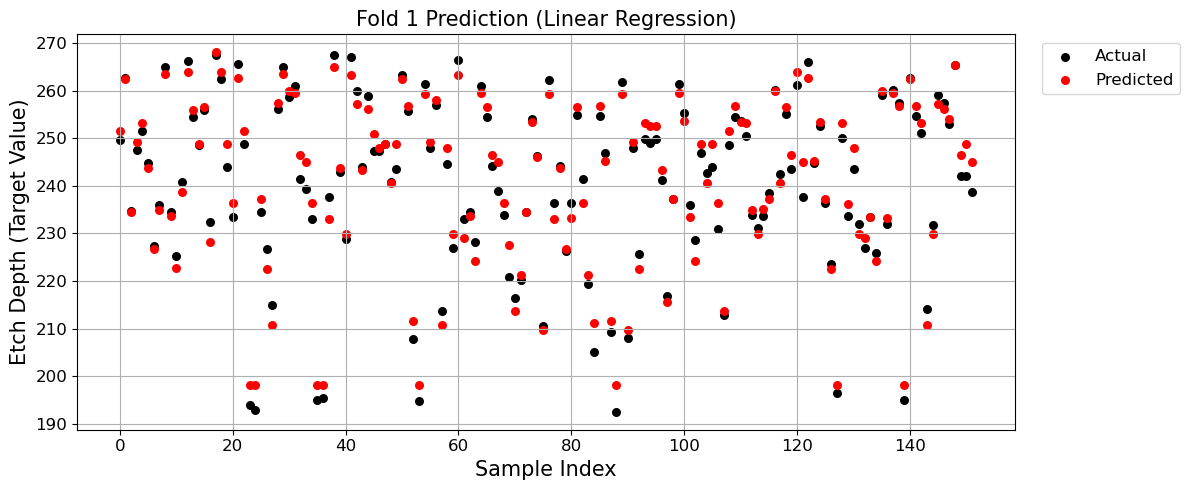


Fold 2
  RMSE: 2.945
  MAE : 2.346
  R^2: 0.976


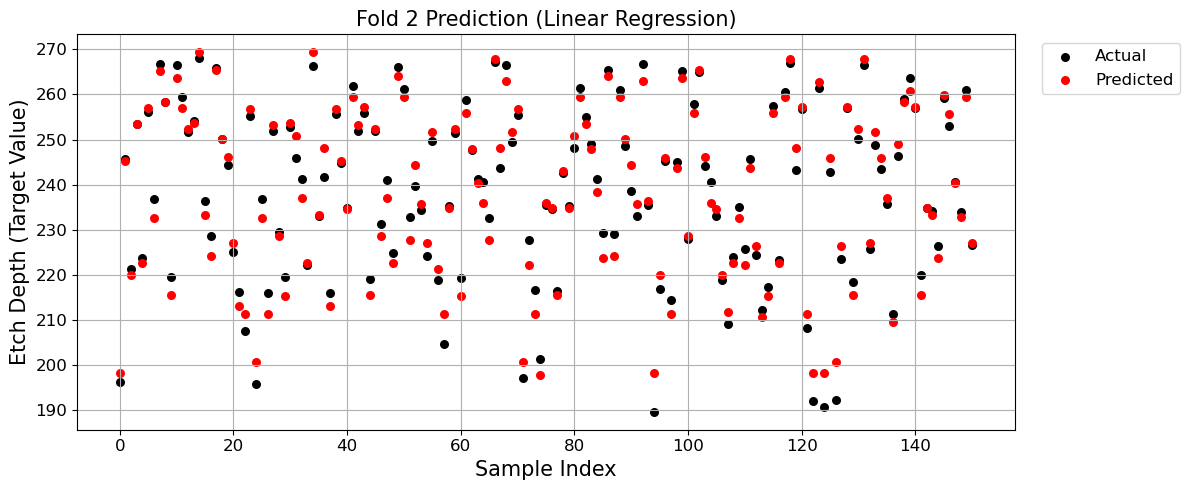


Fold 3
  RMSE: 2.717
  MAE : 2.063
  R^2: 0.979


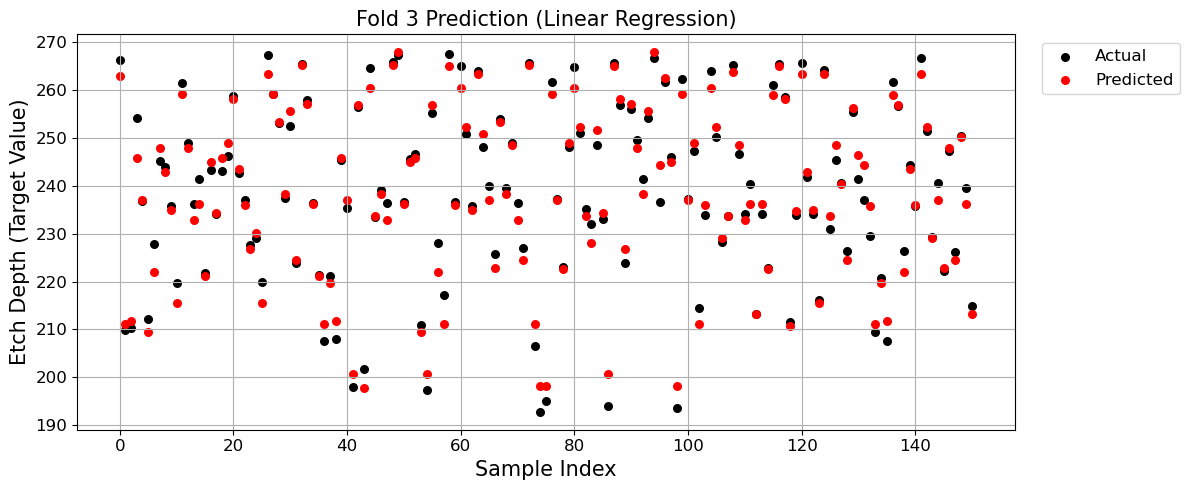


Fold 4
  RMSE: 2.451
  MAE : 1.957
  R^2: 0.983


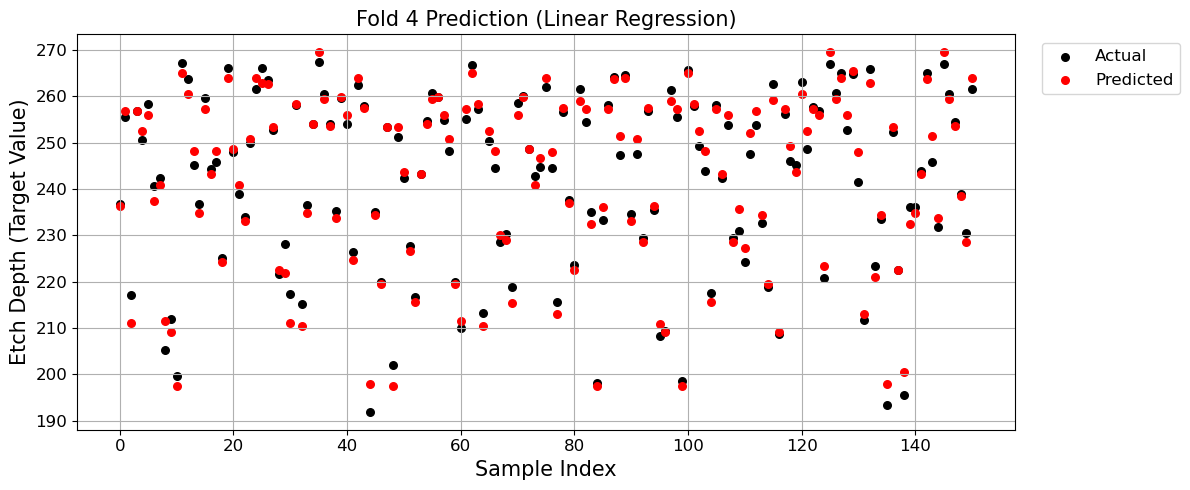


Fold 5
  RMSE: 2.540
  MAE : 2.088
  R^2: 0.981


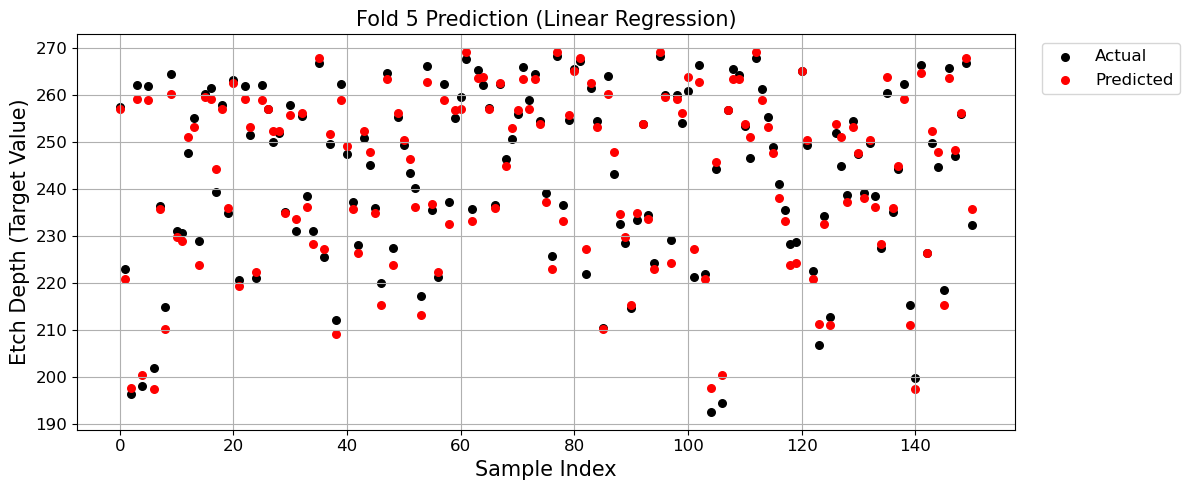


=== average SHAP ===


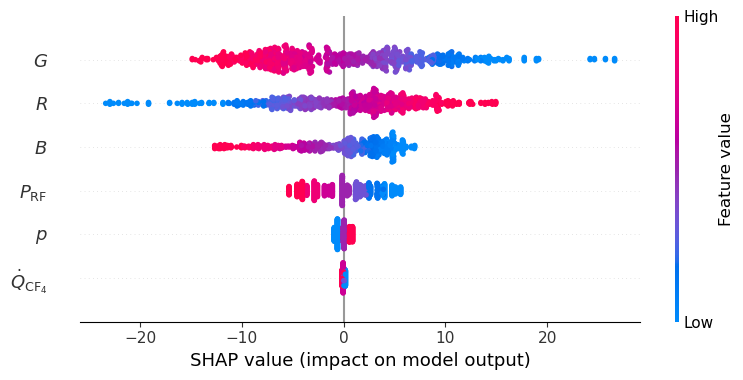

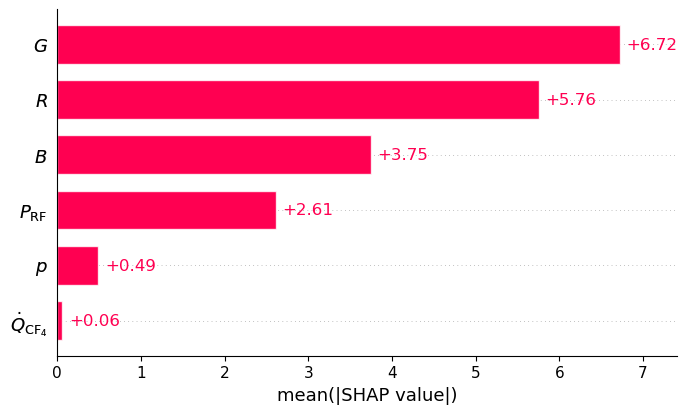


=== Cross-Validation Results ===
Average RMSE: 2.697 ± 0.182
Average MAE : 2.154 ± 0.151
Average R^2: 0.979 ± 0.003


In [ ]:
# LR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 5-Fold 교차검증 및 시각화
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_list = []
mae_list = [] 
r2_list = []
fold_predictions_lr = []

coef_list = []
shap_values_all = []
X_explain_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all)):
    print(f'\nFold {fold+1}')
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'  RMSE: {rmse:.3f}')
    print(f'  MAE : {mae:.3f}')
    print(f'  R^2: {r2:.3f}')
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    fold_predictions_lr.append(y_pred)

    explainer = shap.Explainer(model, X_test, feature_names=feature_names)
    shap_values = explainer(X_test)

    shap_values_all.append(shap_values.values)
    X_explain_all.append(X_test)
    
    plt.figure(figsize=(12, 5))
    x_axis = np.arange(len(y_test))

    plt.scatter(x_axis, y_test, color='black', label='Actual', s=30)
    plt.scatter(x_axis, y_pred, color='red', label='Predicted', s=30)
    plt.title(f'Fold {fold+1} Prediction (Linear Regression)', fontsize=15)
    plt.xlabel('Sample Index', fontsize=15)
    plt.ylabel('Etch Depth (Target Value)', fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# SHAP 시각화
print('\n=== average SHAP ===')
shap_values_all = np.concatenate(shap_values_all, axis=0)
X_explain_all = np.concatenate(X_explain_all, axis=0)

shap_summary = shap.Explanation(
    values=shap_values_all,
    data=X_explain_all,
    feature_names=feature_names
)
shap.summary_plot(shap_summary, max_display=6)
shap.plots.bar(shap_summary, max_display=6)

# 결과 출력
print('\n=== Cross-Validation Results ===')
print(f'Average RMSE: {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f}')
print(f'Average MAE : {np.mean(mae_list):.3f} ± {np.std(mae_list):.3f}')
print(f'Average R^2: {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}')

Start hyperparameter tuning...

Best parameters found:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best CV RMSE: 1.424

Fold 1
  RMSE: 1.342
  MAE : 1.074
  R^2 : 0.995


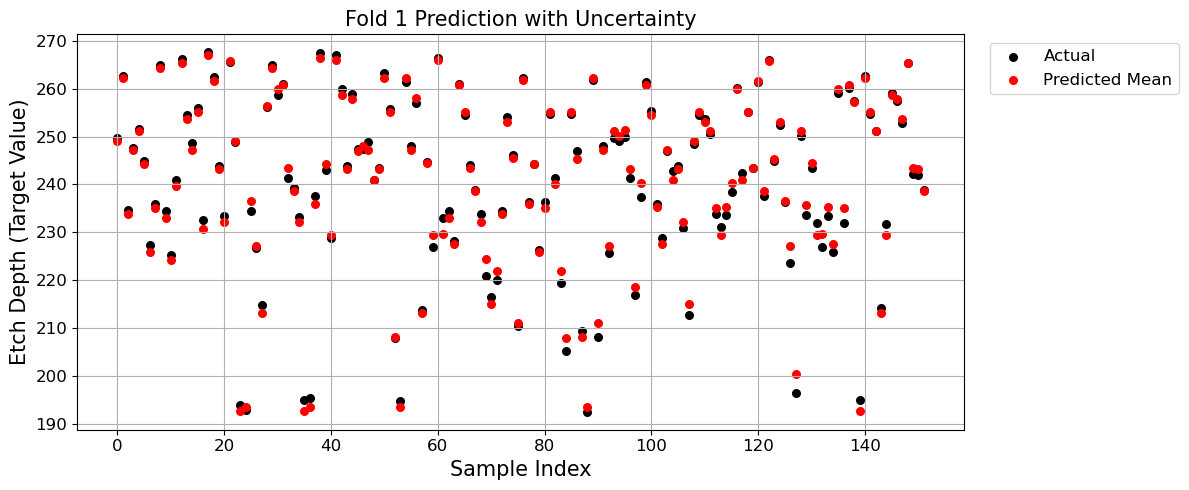


Fold 2
  RMSE: 1.401
  MAE : 1.100
  R^2 : 0.995


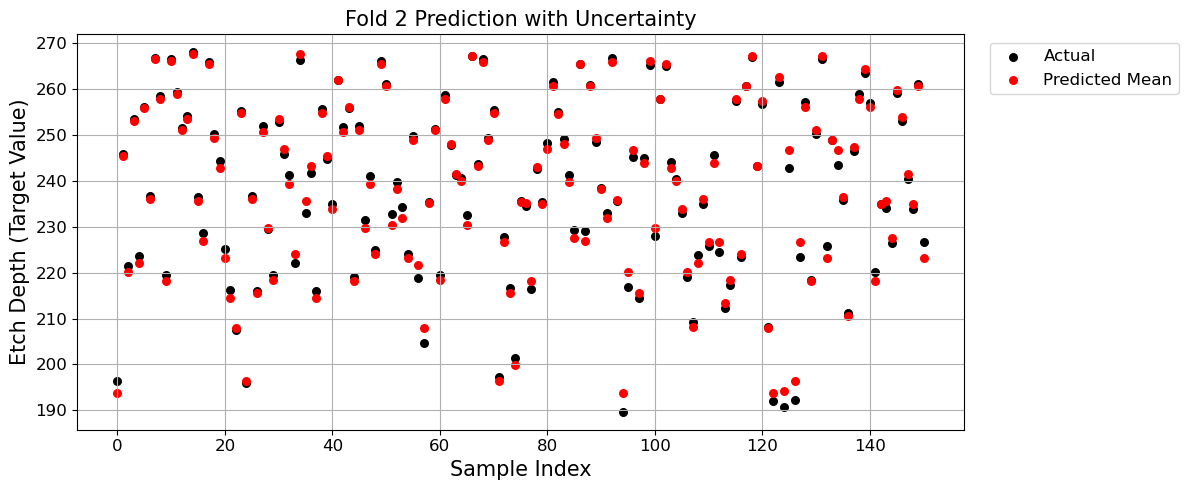


Fold 3
  RMSE: 1.561
  MAE : 1.171
  R^2 : 0.993


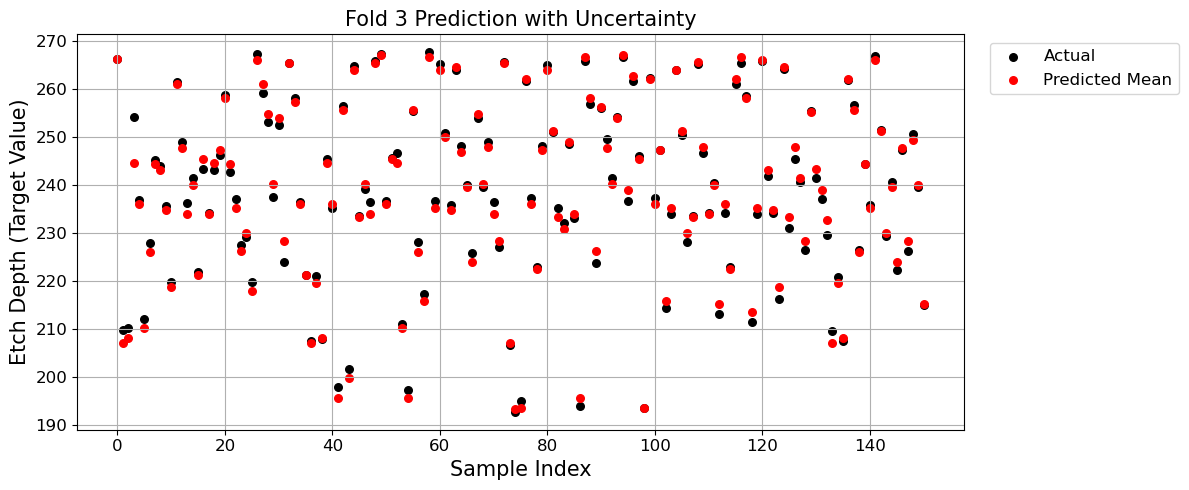


Fold 4
  RMSE: 1.238
  MAE : 1.000
  R^2 : 0.996


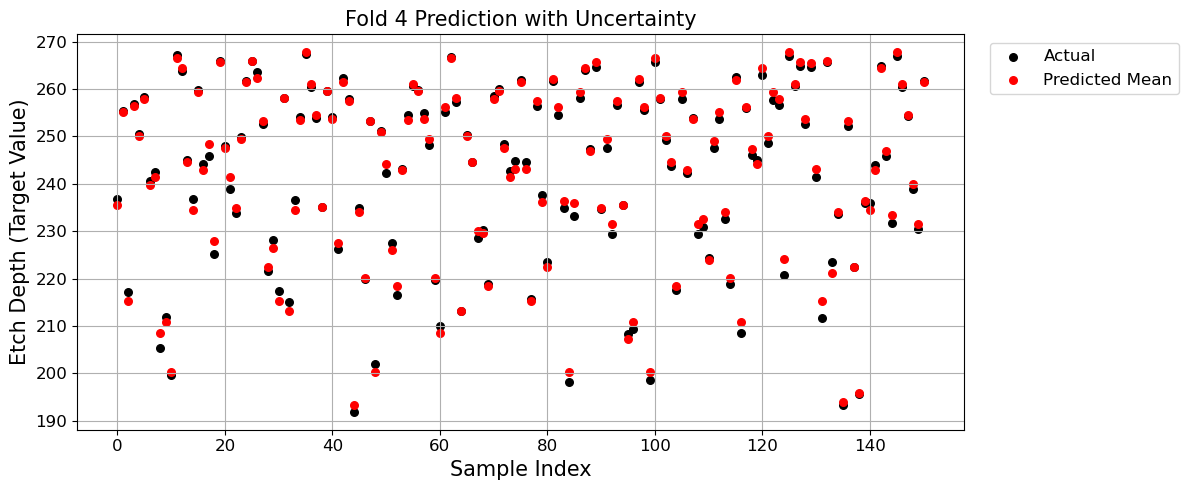


Fold 5
  RMSE: 1.304
  MAE : 1.018
  R^2 : 0.995


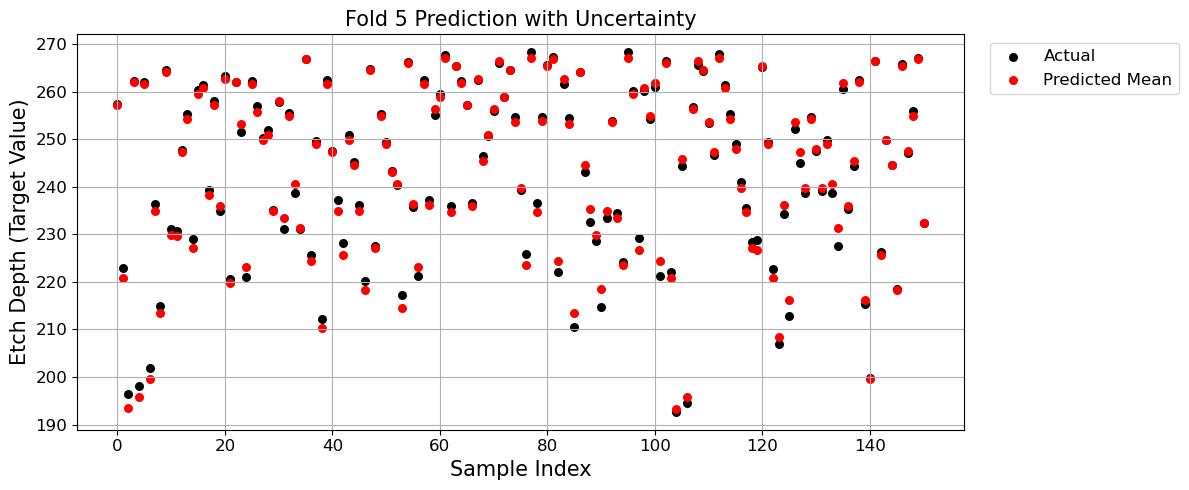


=== average SHAP ===


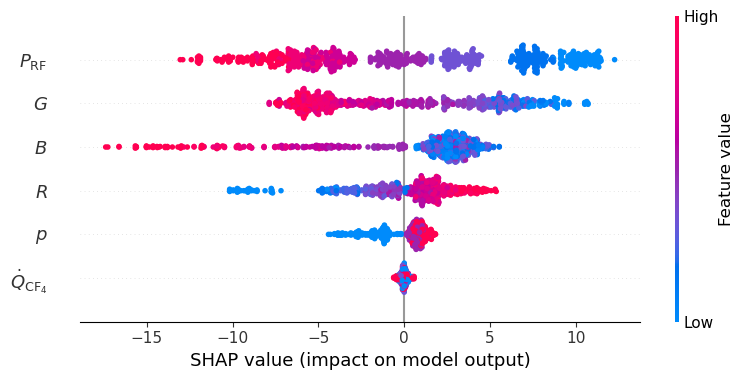

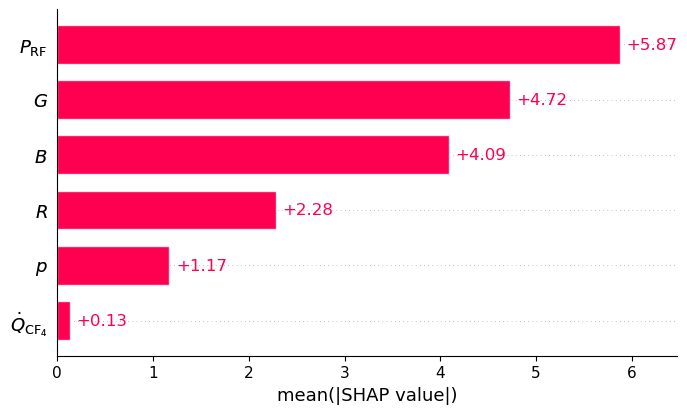


=== Cross-Validation Results ===
Average RMSE: 1.369 ± 0.110
Average MAE : 1.072 ± 0.061
Average R^2: 0.995 ± 0.001


In [ ]:
# RF
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 하이퍼파라미터 탐색
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']  
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=1,            
    verbose=0
)

print("Start hyperparameter tuning...")
random_search.fit(X_all, y_all)

print("\nBest parameters found:")
print(random_search.best_params_)

print(f"Best CV RMSE: {np.sqrt(-random_search.best_score_):.3f}")

best_params = random_search.best_params_

# 5-Fold 교차검증 및 시각화
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_list = []
r2_list = []
mae_list = []

fold_predictions_rf = []
fold_targets = [] 
feature_importance_list = []
shap_values_all = []
X_explain_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all)):
    print(f'\nFold {fold+1}')
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    model = RandomForestRegressor(random_state=42, **best_params)
    model.fit(X_train, y_train)

    # 트리별 예측 분포 계산
    all_tree_preds = np.array([tree.predict(X_test) for tree in model.estimators_])
    mean_pred = np.mean(all_tree_preds, axis=0)
    std_pred = np.std(all_tree_preds, axis=0)

    rmse = mean_squared_error(y_test, mean_pred, squared=False)
    mae = mean_absolute_error(y_test, mean_pred)
    r2 = r2_score(y_test, mean_pred)
    
    fold_predictions_rf.append(mean_pred)
    fold_targets.append(y_test) 
    
    print(f'  RMSE: {rmse:.3f}')
    print(f'  MAE : {mae:.3f}')
    print(f'  R^2 : {r2:.3f}')
    
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)
    
    importances = model.feature_importances_
    feature_importance_list.append(importances)

    explainer = shap.TreeExplainer(model, X_test, feature_names=feature_names)
    shap_values = explainer(X_test)

    shap_values_all.append(shap_values.values)
    X_explain_all.append(X_test)
    
    plt.figure(figsize=(12, 5))
    x_axis = np.arange(len(y_test))
    
    plt.scatter(x_axis, y_test, color='black', label='Actual', s=30)
    plt.scatter(x_axis, mean_pred, color='red', label='Predicted Mean', s=30)

    plt.title(f'Fold {fold+1} Prediction with Uncertainty', fontsize=15)
    plt.xlabel('Sample Index', fontsize=15)
    plt.ylabel('Etch Depth (Target Value)', fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# SHAP 시각화
print('\n=== average SHAP ===')
shap_values_all = np.concatenate(shap_values_all, axis=0)
X_explain_all = np.concatenate(X_explain_all, axis=0)

shap_summary = shap.Explanation(
    values=shap_values_all,
    data=X_explain_all,
    feature_names=feature_names
)

shap.summary_plot(shap_summary, max_display=6)
shap.plots.bar(shap_summary, max_display=6)

# 결과 출력
print('\n=== Cross-Validation Results ===')
print(f'Average RMSE: {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f}')
print(f'Average MAE : {np.mean(mae_list):.3f} ± {np.std(mae_list):.3f}')
print(f'Average R^2: {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}')


In [ ]:
# 노이즈 추가
import importlib
import noise

importlib.reload(noise)

X_all, y_all, feature_names = noise.noise(add_noise=True)


Fold 1
Early stopping at epoch 473
  RMSE: 1.820
  MAE : 1.404
  R^2 : 0.990


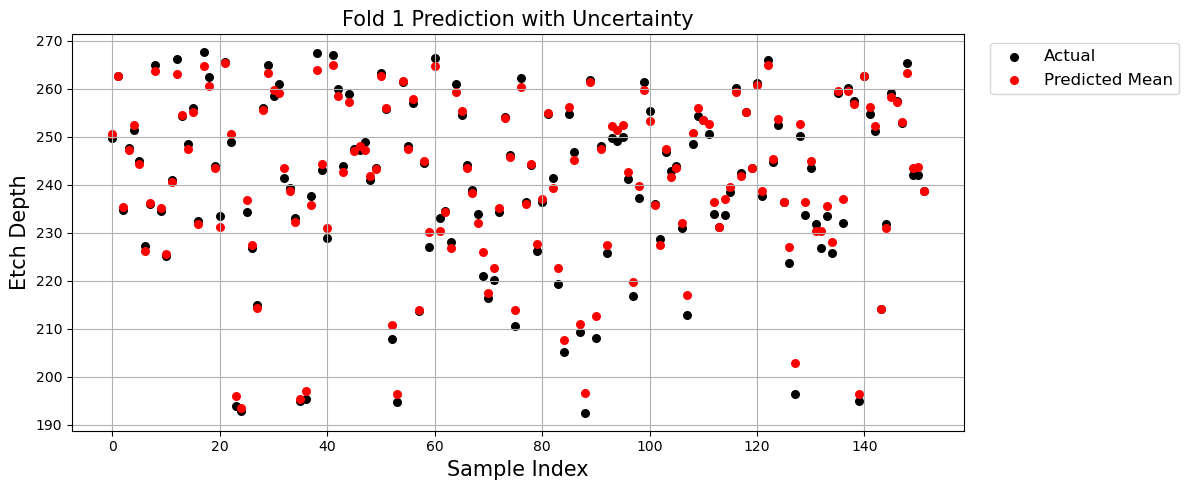

  0%|          | 0/50 [00:00<?, ?it/s]


Fold 2
Early stopping at epoch 397
  RMSE: 2.085
  MAE : 1.497
  R^2 : 0.988


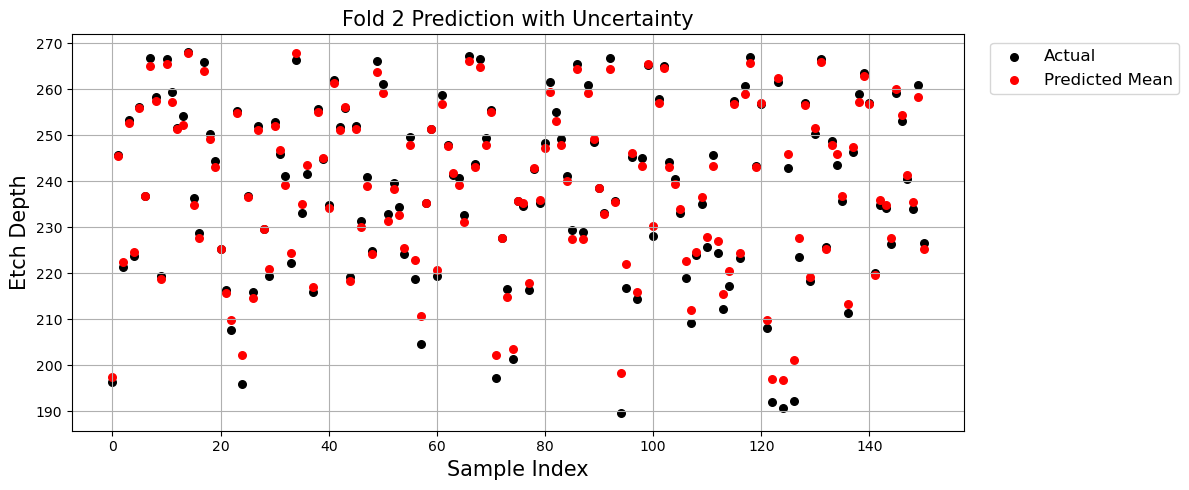

  0%|          | 0/50 [00:00<?, ?it/s]


Fold 3
Early stopping at epoch 429
  RMSE: 1.849
  MAE : 1.383
  R^2 : 0.990


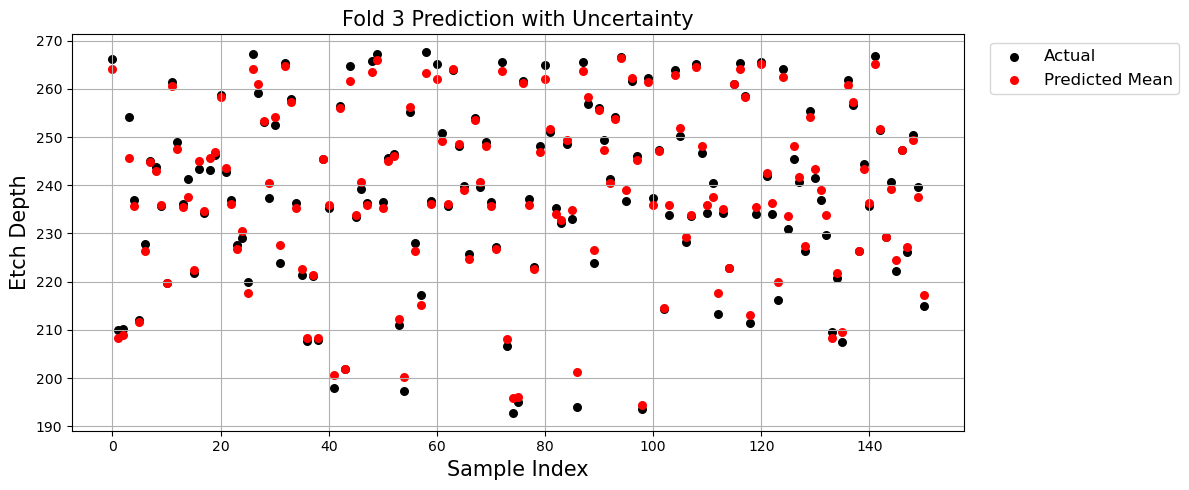

  0%|          | 0/50 [00:00<?, ?it/s]


Fold 4
Early stopping at epoch 275
  RMSE: 1.872
  MAE : 1.512
  R^2 : 0.990


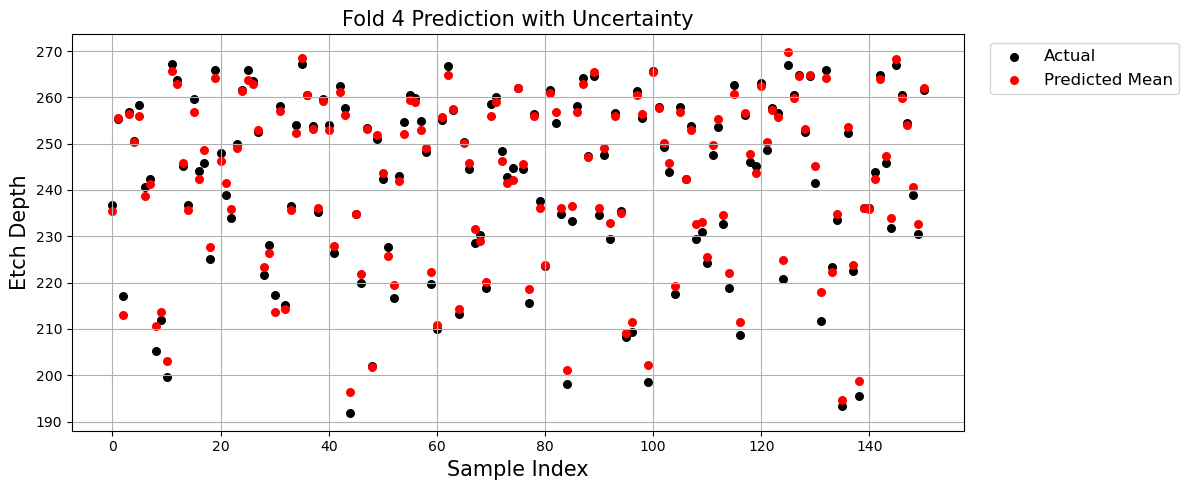

  0%|          | 0/50 [00:00<?, ?it/s]


Fold 5
Early stopping at epoch 163
  RMSE: 2.263
  MAE : 1.824
  R^2 : 0.985


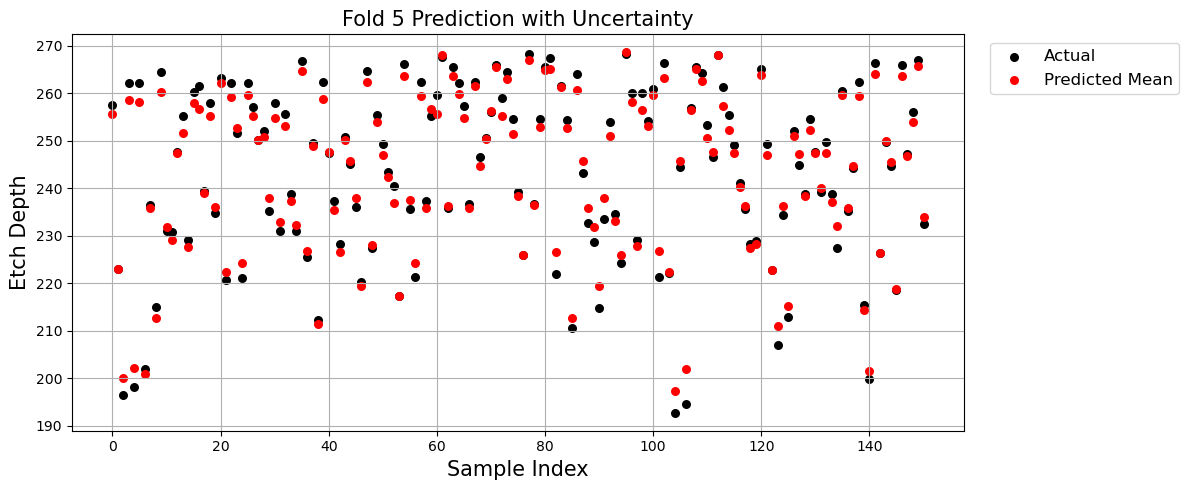

  0%|          | 0/50 [00:00<?, ?it/s]


=== average SHAP ===


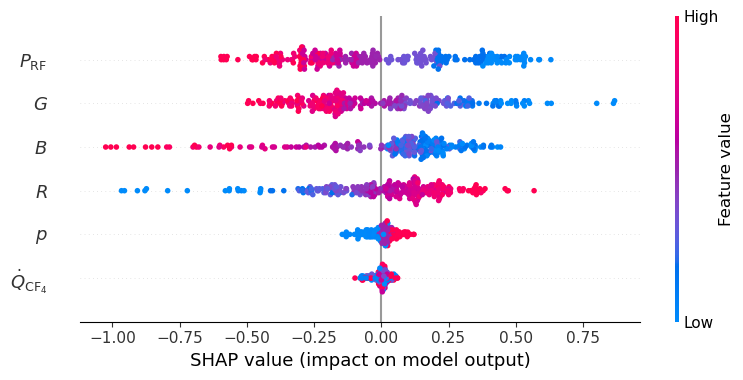

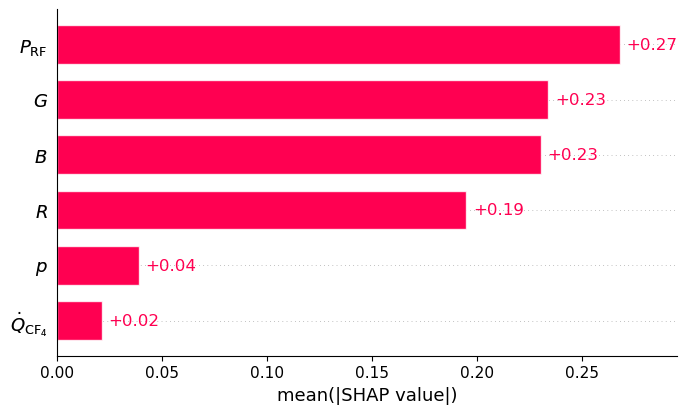


=== Cross-Validation Results ===
Average RMSE: 1.978 ± 0.171
Average MAE : 1.524 ± 0.158
Average R^2 : 0.989 ± 0.002


In [ ]:
# ANN
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import copy
import random
from torch.utils.data import TensorDataset, DataLoader

# 시드 고정 함수
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ANN 모델 정의
class ANNWithDropout(nn.Module):
    def __init__(self, input_dim):
        super(ANNWithDropout, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)

# 5-Fold 교차검증 및 시각화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_list, mae_list, r2_list, uncertainty_list = [], [], [], []
fold_predictions_ann = []
shap_values_all = []
X_explain_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_all)):
    print(f"\nFold {fold+1}")
    set_seed(42 + fold)

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    # DataLoader (Batch 학습 : 메모리 효율성 + 계산 안정성 + GPU 최적화 + 일반화 성능 향상)
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    
    model = ANNWithDropout(X_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    # 학습 루프
    patience = 100
    best_loss = float("inf")
    counter = 0

    for epoch in range(2000):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= len(train_loader)

        # EarlyStopping 체크
        if epoch_loss < best_loss - 1e-5:
            best_loss = epoch_loss
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_state)

    # MC Dropout 예측 
    model.train()
    preds_list = []
    with torch.no_grad():
        for _ in range(100):
            preds = model(X_test_tensor)
            preds_list.append(preds.cpu().numpy())

    preds_array = np.stack(preds_list, axis=0).squeeze()
    mean_pred_scaled = preds_array.mean(axis=0)
    std_pred_scaled = preds_array.std(axis=0)

    mean_pred = scaler_y.inverse_transform(mean_pred_scaled.reshape(-1, 1)).flatten()
    std_pred = std_pred_scaled * scaler_y.scale_[0]

    rmse = mean_squared_error(y_test, mean_pred, squared=False)
    mae = mean_absolute_error(y_test, mean_pred)
    r2 = r2_score(y_test, mean_pred)
    
    fold_predictions_ann.append(mean_pred)

    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE : {mae:.3f}")
    print(f"  R^2 : {r2:.3f}")

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

    x_axis = np.arange(len(y_test))
    plt.figure(figsize=(12, 5))
    plt.scatter(x_axis, y_test, label="Actual", color="black", s=30)
    plt.scatter(x_axis, mean_pred, label="Predicted Mean", color="red", s=30)
    plt.title(f"Fold {fold+1} Prediction with Uncertainty", fontsize=15)
    plt.xlabel("Sample Index", fontsize=15)
    plt.ylabel("Etch Depth", fontsize=15)
    plt.legend(fontsize=12, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    def predict_fn(x_numpy):
        x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
        model.train()
        with torch.no_grad():
            preds = []
            for _ in range(30):
                pred = model(x_tensor).cpu().numpy()
                preds.append(pred)
            return np.mean(np.stack(preds, axis=0), axis=0)

    background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], size=50, replace=False)]
    explainer = shap.KernelExplainer(predict_fn, background)
    shap_values = explainer.shap_values(X_test_scaled[:50], nsamples=100)
    shap_values_all.append(shap_values[0])
    X_explain_all.append(X_test_scaled[:50])



# SHAP 시각화
print('\n=== average SHAP ===')
shap_values_all = np.concatenate(shap_values_all, axis=0)
X_explain_all = np.concatenate(X_explain_all, axis=0)

shap_summary = shap.Explanation(values=shap_values_all, data=X_explain_all, feature_names=feature_names)
shap.summary_plot(shap_summary, max_display=6)
shap.plots.bar(shap_summary, max_display=6)

# 결과
print('\n=== Cross-Validation Results ===')
print(f'Average RMSE: {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f}')
print(f'Average MAE : {np.mean(mae_list):.3f} ± {np.std(mae_list):.3f}')
print(f'Average R^2 : {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}')



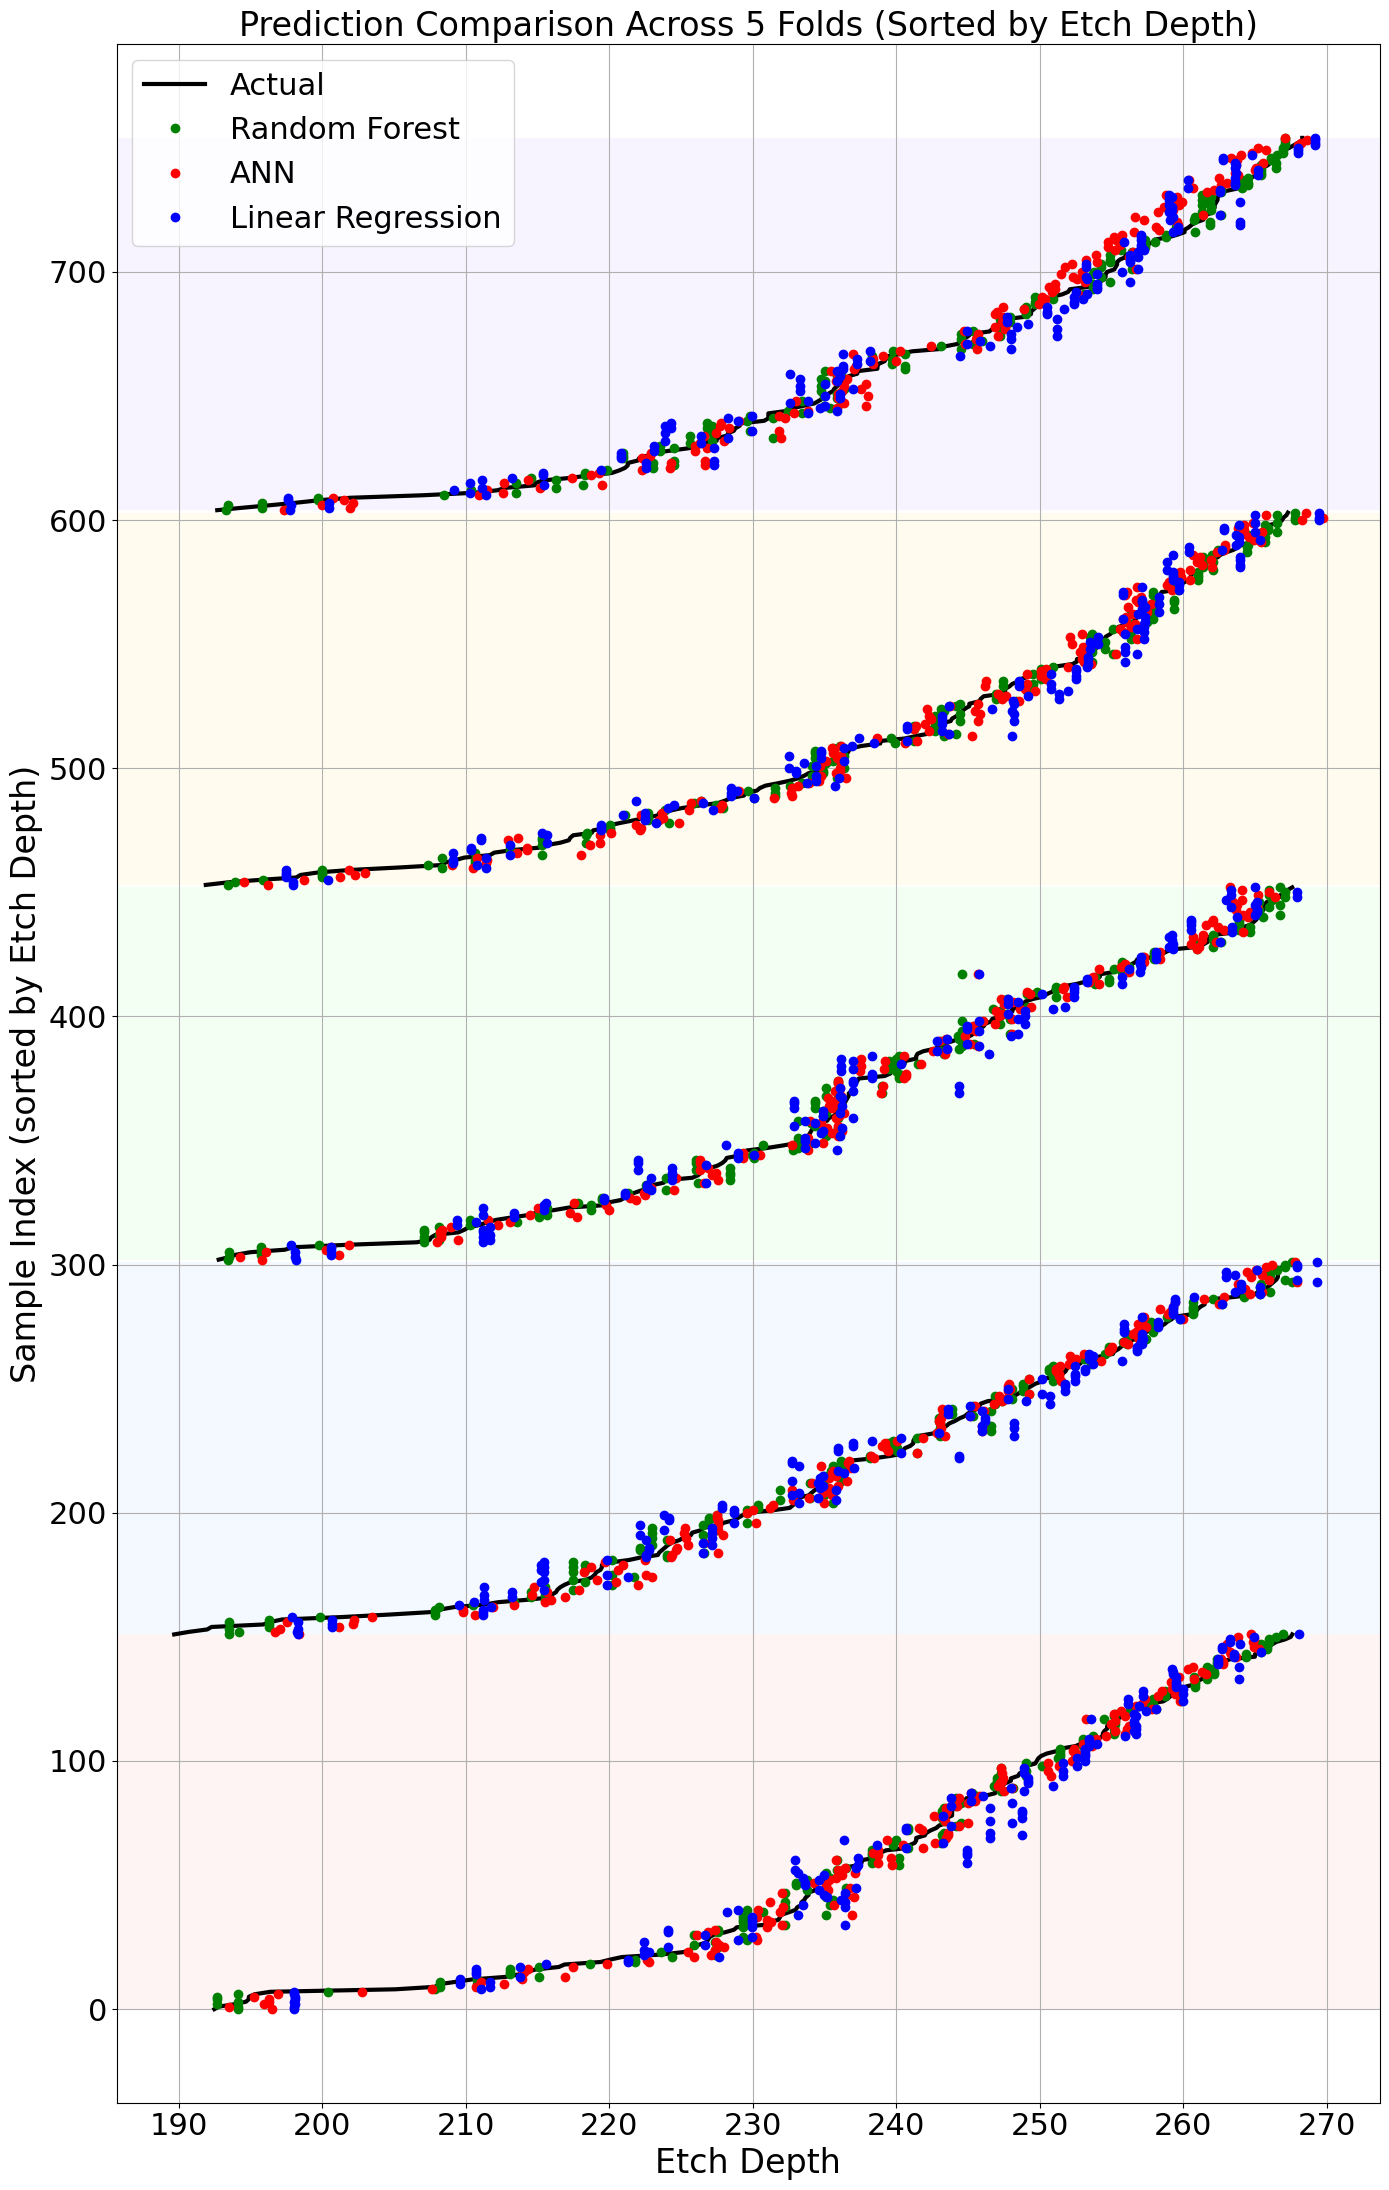

In [ ]:
plt.figure(figsize=(14, 22))

colors = ["#ffcccc", "#cce5ff", "#ccffcc", "#fff0b3", "#e0ccff"]

for fold in range(5):
    y_true = fold_targets[fold]
    y_rf   = fold_predictions_rf[fold]
    y_lr   = fold_predictions_lr[fold]
    y_ann  = fold_predictions_ann[fold]

    # Etch depth 기준 정렬
    sort_idx = np.argsort(y_true)
    y_true_sorted = y_true[sort_idx]
    y_rf_sorted   = y_rf[sort_idx]
    y_lr_sorted   = y_lr[sort_idx]
    y_ann_sorted  = y_ann[sort_idx]

    x_axis = np.arange(len(y_true_sorted)) + fold * len(y_true_sorted)

    # fold별 영역 배경색
    ymin, ymax = x_axis.min(), x_axis.max()
    plt.axhspan(ymin, ymax, facecolor=colors[fold], alpha=0.2)

    plt.plot(y_true_sorted, x_axis, 'k-', linewidth=3, label="Actual" if fold == 0 else "")
    plt.plot(y_rf_sorted,   x_axis, 'go', label="Random Forest" if fold == 0 else "")
    plt.plot(y_ann_sorted,  x_axis, 'ro', label="ANN" if fold == 0 else "")
    plt.plot(y_lr_sorted,   x_axis, 'bo', label="Linear Regression" if fold == 0 else "")

plt.title("Prediction Comparison Across 5 Folds (Sorted by Etch Depth)", fontsize=24)
plt.xlabel("Etch Depth", fontsize=24)
plt.ylabel("Sample Index (sorted by Etch Depth)", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(True)
plt.legend(fontsize=22)
plt.tight_layout()
plt.show()
